In [305]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [306]:
sns.set(style="whitegrid")

# Проект: Предсказываем, откроет ли клиент вклад в банке после маркетингового звонка

## Загрузка данных

Используем датасет [Bank Marketing Campaign](https://www.kaggle.com/code/janiobachmann/bank-marketing-campaign-opening-a-term-deposit)

**Признаки:**

`age` возраст

`job` тип работы

`marital` семейное положение

`education` уровень образования

`default` есть ли задолженности по кредитам

`housing` есть ли ипотека

`loan` есть ли потребительский кредит

`balance` среднее количество денег на счете за год

`contact` метод связи с клиентом

`month` месяц, в который в предыдущий раз связывались с клиентом

`day_of_week` день недели, в который в предыдущий раз связывались с клиентом

`duration` продолжительность предыдущего разговора с клиентом

`campaign` сколько раз связывались с клиентом во время текущей маркетинговой кампании

`pdays` сколько дней прошло с последнего контакта с клиентом во время предыдущей кампании (-1 означает, что с клиентом не связывались в предыдущих кампаниях)

`previous` сколько раз связывались с клиентом во время предыдущих кампаний

`poutcome` результат предыдущей маркетинговой кампании (открыл ли клиент вклад по ее результатам)

**Целевой признак**: `deposit` открыл ли клиент вклад в результате маркетингового звонка

## Цель работы

В этой работе будем стараться предсказать, откроет ли клиент вклад по итогам маркетингового звонка

Будем исходить из соображений, что банк хочет сэкономить на звонках и не обзванивать клиентов, которые с низкой вероятностью откроют вклад

In [307]:
df = pd.read_csv("bank.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [308]:
df.shape

(11162, 17)

In [309]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


Пропусков в данных нет:

In [310]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [311]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


## Предварительный анализ

Посмотрим, как некоторые из признаков влияют на целевую перменную

Распределение целевой переменной практически равномерно:

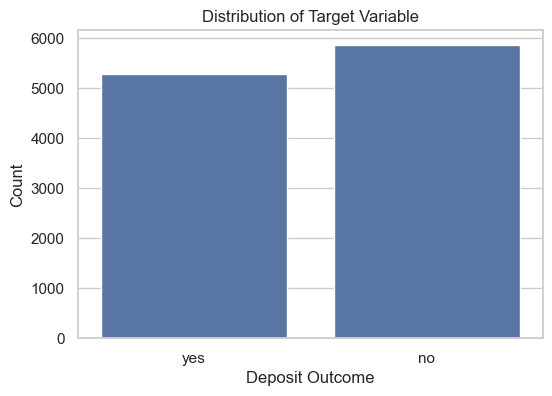

In [312]:
plt.figure(figsize=(6,4))

sns.countplot(x='deposit', data=df)

plt.title("Distribution of Target Variable")
plt.xlabel("Deposit Outcome")
plt.ylabel("Count")

plt.show()

Видим асимметричное распределение возраста и баланса.

Меньшее количество клиентов старше 60 можно объяснить тем, что старшее поколение может предпочитать хранить деньги в наличном виде или вкладывать в недвижимость

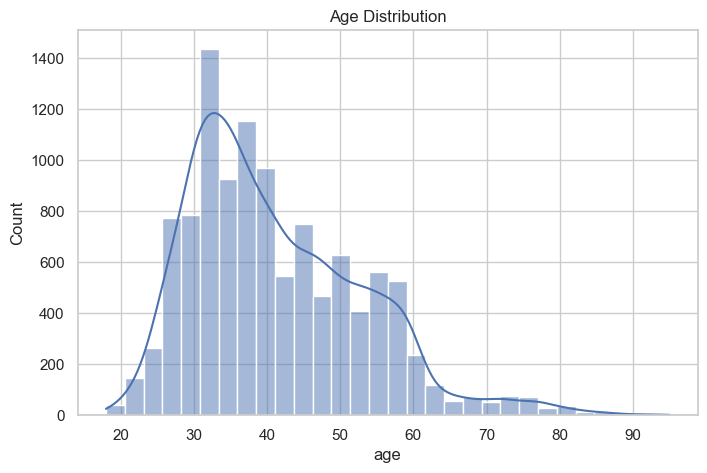

In [313]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=30, kde=True)

plt.title("Age Distribution")
plt.show()

В случае с балансом видим очень сильную асимметрию из-за небольшого количества клиентов с балансом > 10 000

In [314]:
df["balance"].describe()

count    11162.000000
mean      1528.538524
std       3225.413326
min      -6847.000000
25%        122.000000
50%        550.000000
75%       1708.000000
max      81204.000000
Name: balance, dtype: float64

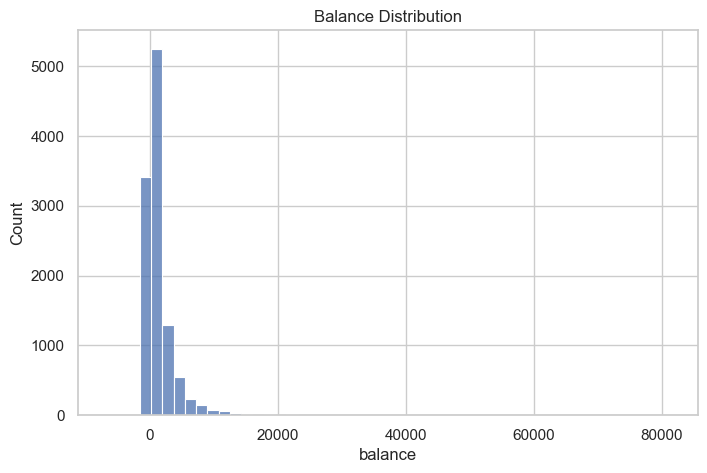

In [315]:
plt.figure(figsize=(8,5))

sns.histplot(df['balance'], bins=50)

plt.title("Balance Distribution")
plt.show()

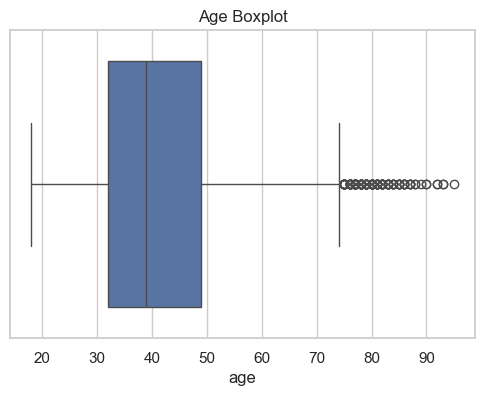

In [316]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df['age'])

plt.title("Age Boxplot")
plt.show()

У возраста клиентов, открывших вклад, больше IQR. Медианы возрастов у двух групп достаточно близки, но группа, открывшая вклад, более разнообразна по возрасту

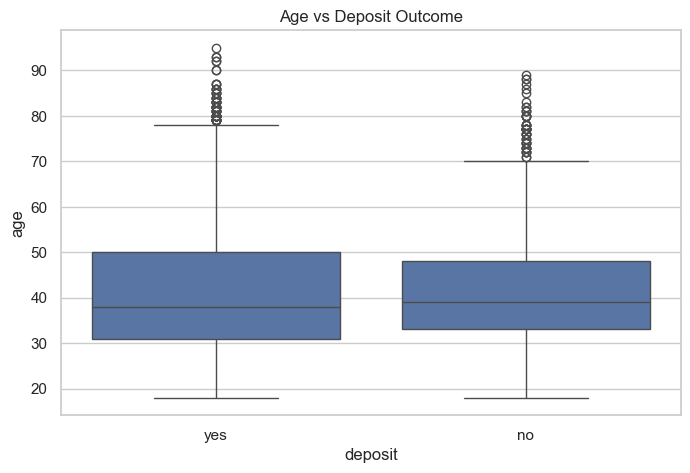

In [317]:
plt.figure(figsize=(8,5))

sns.boxplot(x='deposit', y='age', data=df)

plt.title("Age vs Deposit Outcome")
plt.show()

Группы по роду деятельности, чаще всего открывавшие вклад — студенты и пенсионеры. Пенсионеры могут предпочитать консерввативные виды дохода (такие, как вклады)

При этом от группы студентов можно было ожидать меньшего уровня открытия вкладов, так как в молодом возрасте у человека с меньшей вероятностью могут быть свободные средства, которые можно положить на вклад на фиксированный срок

Следует помнить, что мы видим статистику среди тех, кому звонили. Возможно, проводился отбор клиентов, которым совершались звонки. В таком случае банк мог изначально решить обзванивать только более обеспеченных студентов

Реже всего вклады открывали представители `blue collar` и предпприниматели. Можно предположить, что большинство предпринимателей владеют малым бизнесом, приносящим сравнительно небольшой доход, и не располагают суммой, от которой могут отказаться на несколько месяцев

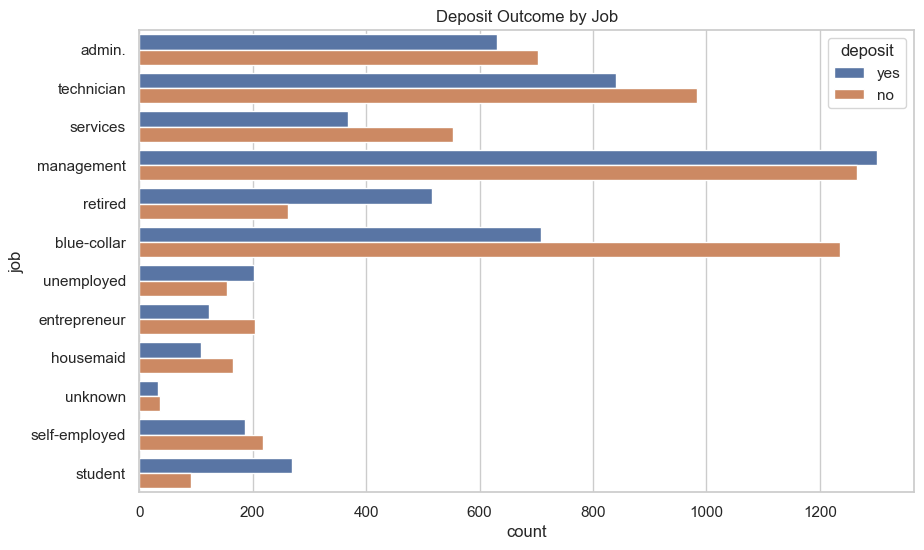

In [318]:
plt.figure(figsize=(10,6))

sns.countplot(y='job', hue='deposit', data=df)

plt.title("Deposit Outcome by Job")

plt.show()

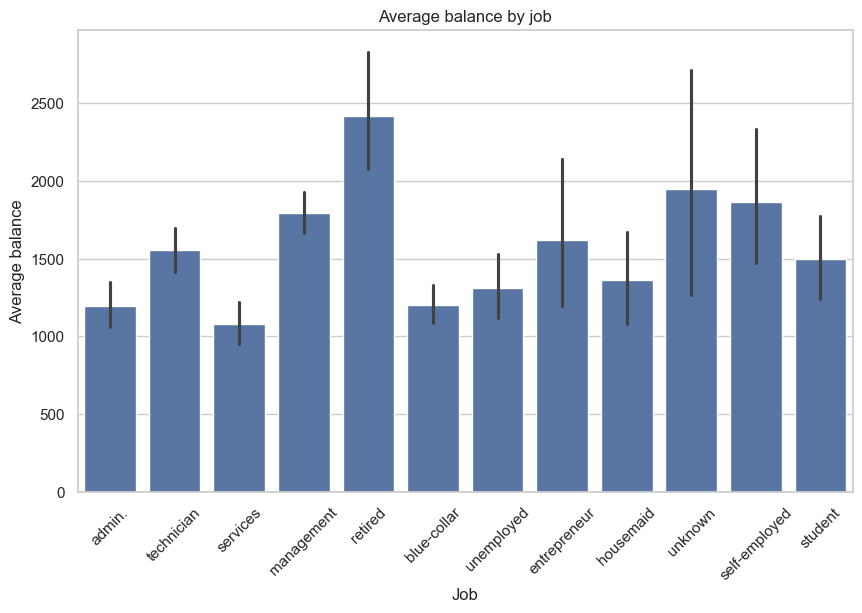

In [319]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='job',
    y='balance',
    data=df,
    estimator=np.mean
)

plt.xticks(rotation=45)

plt.title("Average balance by job")
plt.ylabel("Average balance")
plt.xlabel("Job")

plt.show()

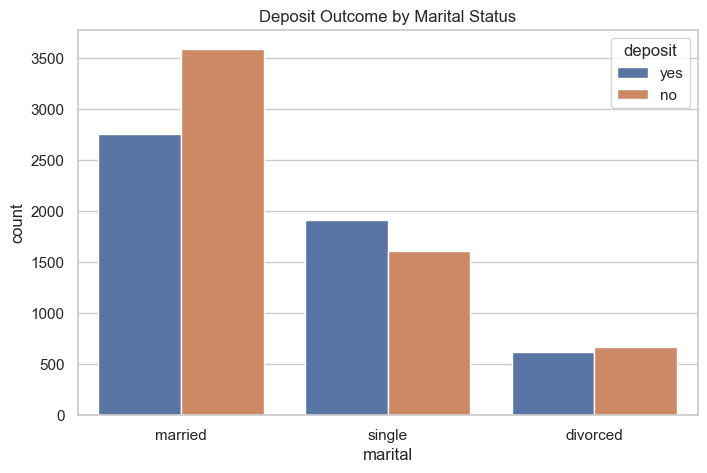

In [320]:
plt.figure(figsize=(8,5))

sns.countplot(x='marital', hue='deposit', data=df)

plt.title("Deposit Outcome by Marital Status")
plt.show()

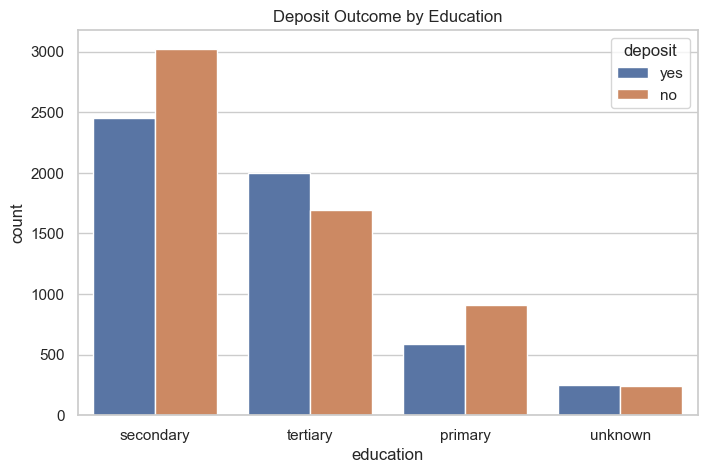

In [321]:
plt.figure(figsize=(8,5))

sns.countplot(x='education', hue='deposit', data=df)

plt.title("Deposit Outcome by Education")
plt.show()

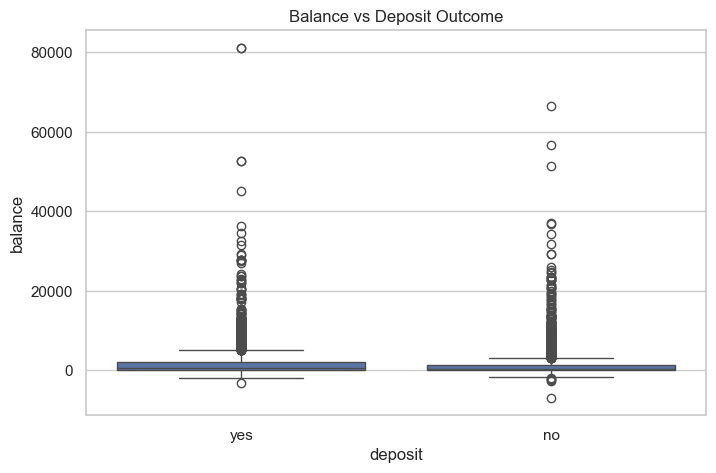

In [322]:
plt.figure(figsize=(8,5))

sns.boxplot(x='deposit', y='balance', data=df)

plt.title("Balance vs Deposit Outcome")
plt.show()

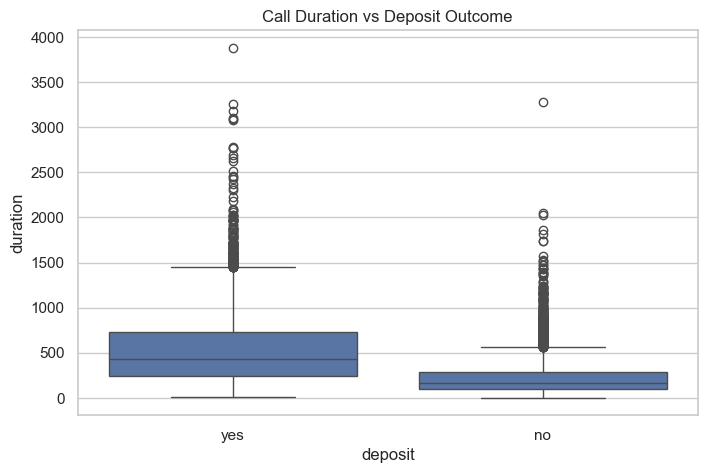

In [323]:
plt.figure(figsize=(8,5))

sns.boxplot(x='deposit', y='duration', data=df)

plt.title("Call Duration vs Deposit Outcome")
plt.show()

In [324]:
df['deposit'] = df['deposit'].map({"yes": 1, "no": 0})

In [325]:
df['pdays'].describe()

count    11162.000000
mean        51.330407
std        108.758282
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         20.750000
max        854.000000
Name: pdays, dtype: float64

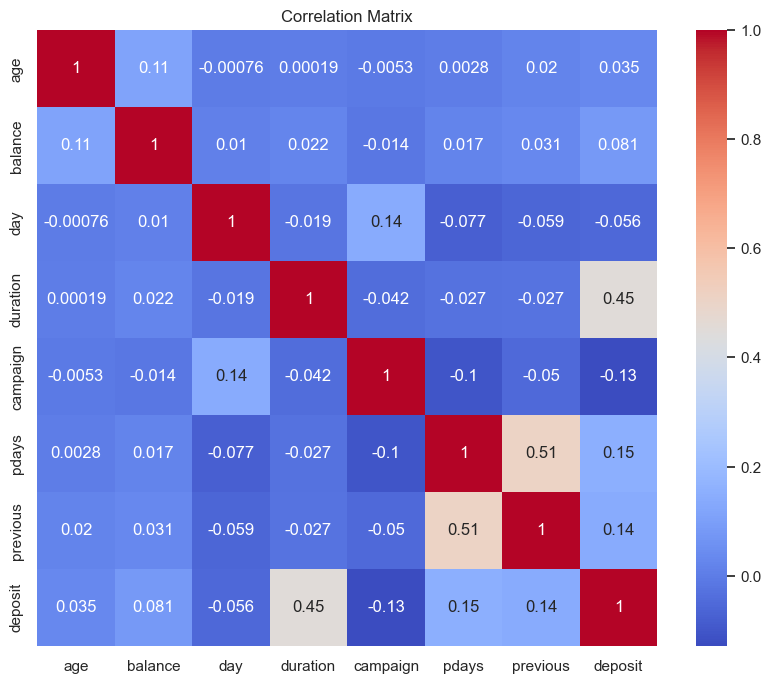

In [326]:
numeric_cols = df.select_dtypes(include="number")

corr = numeric_cols.corr()

plt.figure(figsize=(10,8))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

## Подготовка данных

Удалим признак `duration`, чтобы избежать утечки данных

В этой работе поставлена цель предсказать, стоит ли звонить клиенту (есть ли смысл тратить деньги на звонок ему)

Во-первых, `duration` достаточно сильно связан с целевой переменной, ведь если `duration = 0`, то мы точно знаем, что кампания оказалась неуспешной для этого клиента

Во-вторых, продолжительность звонка становится нам известна только тогда, когда звонок уже завершен, а к этому моменту нам известен и результат (успешность) звонка

In [327]:
df.drop("duration", axis=1, inplace=True)

Добавим признак `was_contacted_before`, выведенный из `pdays`

In [328]:
df["was_contacted_before"] = (df["pdays"] != -1).astype(int)
df["pdays"] = df["pdays"].replace(-1, 0)

In [329]:
X = df.drop("deposit", axis=1)
y = df["deposit"]

In [330]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [331]:
numeric_features = X.select_dtypes(include=["int64","float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

In [332]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [333]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [334]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

Подготовим функцию для оценки работы моделей. Будем использовать следующие метрики:

- **Accuracy**. Доля правильно классифицированных наблюдений среди всех объектов
- **Precision**. Насколько часто модель оказывается права, когда предсказывает, что клиент откроет вклад. Поскольку мы исходим из соображений минимизации расходов, а не привлечения максимального возможного количества клиентов, будем обращать больше внимания на эту метрику
- **Recall**. Показывает, какую долю от всех клиентов, открыших вклад, модель смогла правильно предсказать
- **F1-score**. Гармоническое среднее между Accuracy и Recall

In [335]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    metrics = {}

    metrics["accuracy"] = accuracy_score(y_test, y_pred)
    metrics["precision"] = precision_score(y_test, y_pred)
    metrics["recall"] = recall_score(y_test, y_pred)
    metrics["f1"] = f1_score(y_test, y_pred)

    return metrics

In [336]:
results = {}

## Бейзлайн и обучение моделей

Построим бейзлайн модель, предсказывающую всегда самое частое значение целевой переменной, и три модели:

- **Логистическая регрессия**. Базовая модель для решения задач классификации
- **Decision Tree**. Хорошо справляется с нелинейными зависимостями и категориальными данными
- **Random Forest**. Обычно показывает результаты лучше, чем Decisio Tree, устойчива к переобучению

In [337]:
baseline = DummyClassifier(strategy="most_frequent")

baseline_metrics = evaluate_model(
    baseline,
    X_train,
    X_test,
    y_train,
    y_test,
)


results["baseline"] = baseline_metrics

print(baseline_metrics)

{'accuracy': 0.5261979399910435, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}


/home/polyfrog/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [338]:
logreg = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

results["logreg"] = evaluate_model(
    logreg,
    X_train,
    X_test,
    y_train,
    y_test,
)

print(results["logreg"])

{'accuracy': 0.6954769368562472, 'precision': 0.7327586206896551, 'recall': 0.5623818525519849, 'f1': 0.6363636363636364}


Для Decision Tree и Random Forest добавим также признак season. Этот признак скорее запутал бы логистическую регрессию, но может помочь следующим двум моделям найти сезонную закономерность в данных

In [339]:
season_map = {
    "dec":"winter","jan":"winter","feb":"winter",
    "mar":"spring","apr":"spring","may":"spring",
    "jun":"summer","jul":"summer","aug":"summer",
    "sep":"autumn","oct":"autumn","nov":"autumn"
}

df["season"] = df["month"].map(season_map)

In [340]:
tree = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=6,
            random_state=42
        ))
    ]
)

results["decision tree"] = evaluate_model(
    tree,
    X_train,
    X_test,
    y_train,
    y_test,
)

print(results["decision tree"])

{'accuracy': 0.6892073443797582, 'precision': 0.7577903682719547, 'recall': 0.505671077504726, 'f1': 0.6065759637188209}


In [341]:
rf = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=400,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

results["random forest"] = evaluate_model(
    rf,
    X_train,
    X_test,
    y_train,
    y_test,
)

print(results["random forest"])

{'accuracy': 0.7272727272727273, 'precision': 0.7823899371069183, 'recall': 0.5879017013232514, 'f1': 0.671343766864544}


## Анализ результатов

### Logistic Regression
Модель оказывалась права в положительных предсказаниях в 73% случаев. Recall 0.56 говорит о том, что модель обнаруживает больше половины клиентов, действительно открывших депозит

### Decision Tree
Более высокий Precision по сравнению с логистической регрессией (0.75). Но сильно ниже значение Recall (0.5), что сказалось на F1-score это модели: он ниже, чем у остальных и говорит о том, что можель плохо сбалансирована между точностью и полнотой

### Random Forest
Эта модель показала наилучшие результаты. Значение Precision 0.78 говорит о том, что почти 80% положительных прогнозов модели сбываются, при этом Recall остается на том же уровне, что и у Decision Tree. Значение F1-score у этой модели выше, чем у других, говорит о хорошем балансе между точностью и полнотой

In [342]:
pd.DataFrame(results).T

,accuracy,precision,recall,f1
baseline,0.526198,0.000000,0.000000,0.000000
logreg,0.695477,0.732759,0.562382,0.636364
decision tree,0.689207,0.757790,0.505671,0.606576
random forest,0.727273,0.782390,0.587902,0.671344


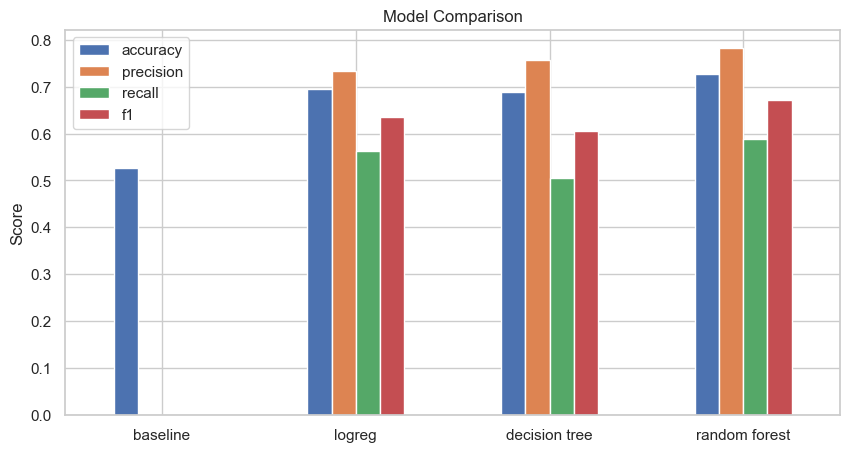

In [347]:
pd.DataFrame(results).T.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Model Comparison")
plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

## Важность признаков в Random Forest

Дополнительно посмотрим на важность признаков, выведенную моделью Random Forest

In [348]:
rf_model = rf.named_steps["model"]
feature_names = rf.named_steps["preprocessing"].get_feature_names_out()
importances = rf_model.feature_importances_

In [349]:
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(20)

,feature,importance
49,cat__poutcome_success,0.102099
0,num__age,0.078428
1,num__balance,0.075864
4,num__pdays,0.067858
34,cat__contact_unknown,0.066007
2,num__day,0.055531
32,cat__contact_cellular,0.046684
28,cat__housing_no,0.039391
29,cat__housing_yes,0.038724
3,num__campaign,0.035736


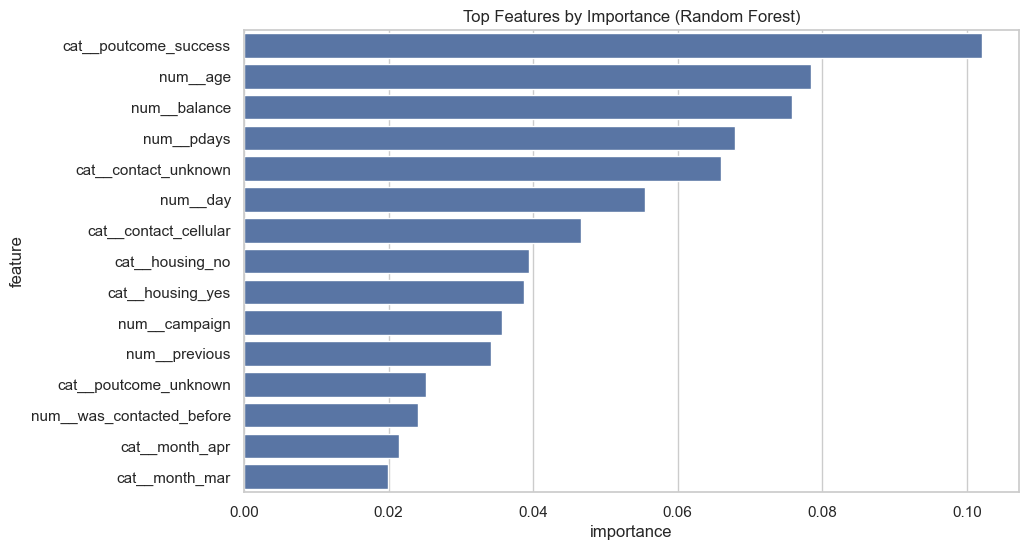

In [350]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x="importance",
    y="feature"
)

plt.title("Top Features by Importance (Random Forest)")

plt.show()

# Итоги

Наилучшие результаты показала модель Random Forest, причем она оказалась оптимальной не только для поставленной нами задачи (снижение затрат на звонки), но и по другим метрикам тоже: например, она находит бо́льшую долю от клиентов, открывших счет